# In-Session Evolution Analysis

This notebook analyzes how intent labels evolve within each session (`sha`) using normalized message position in $[0, 1]$.

Core rules implemented in this notebook:
- Session unit is `sha`.
- Multi-label messages use equal fractional contribution so each message contributes a total of 1.
- Short sessions are filtered by a configurable threshold (`MIN_MESSAGES`).
- Evolution is computed via normalized message position within each session
- Additional evolution metrics include message length (`# chars`) and number of labels (`# labels`).

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_theme(style="whitegrid")

# Paths and toggles
DATA_PATH = Path("../data/classifications/classifications_for_analysis.csv")
SAVE_RESULTS = False
RESULTS_DIR = Path("results")
EXCLUDE_OPENING = True  # Set True to drop each session's first message before analysis.

# Analysis configuration
MIN_MESSAGES = 1  # Exclude sessions with fewer than this many messages.
SMOOTH_GRID_SIZE = (
    None  # Auto-set to max session length after session stats are computed.
)
TOP_K_MAIN = 8
TOP_K_SUB = 15
RANDOM_SEED = 42

np.random.seed(RANDOM_SEED)

if SAVE_RESULTS:
    RESULTS_DIR.mkdir(parents=True, exist_ok=True)

print(f"Data path: {DATA_PATH.resolve()}")
print(f"MIN_MESSAGES: {MIN_MESSAGES}")
print(f"SAVE_RESULTS: {SAVE_RESULTS}")
print(f"EXCLUDE_OPENING: {EXCLUDE_OPENING}")
print("SMOOTH_GRID_SIZE: auto (max session length)")

Data path: /Users/ningzhi_tang/Documents/VSCodeProjects/empirical-conversational-programming/data/classifications/classifications_for_analysis.csv
MIN_MESSAGES: 1
SAVE_RESULTS: False
EXCLUDE_OPENING: True
SMOOTH_GRID_SIZE: auto (max session length)


In [2]:
REQUIRED_COLUMNS = ["sha", "index_in_chat", "main_category", "sub_category"]
OPTIONAL_COLUMNS = ["content", "label_rank"]


def validate_columns(df: pd.DataFrame) -> None:
    missing = [c for c in REQUIRED_COLUMNS if c not in df.columns]
    if missing:
        raise ValueError(f"Missing required columns: {missing}")


def session_equal_weight_curve_from_sequences(
    sequences: dict[str, np.ndarray],
    grid_size: int,
) -> pd.DataFrame:
    """Compute grid curve where each session contributes equally at each grid point.

    For each grid point g in [0, 1], each session contributes one interpolated value.
    Final value is the simple average across sessions (session-equal weighting).
    """
    grid = np.linspace(0.0, 1.0, grid_size)
    if not sequences:
        return pd.DataFrame(
            {
                "pos_norm": grid,
                "value_interp": np.zeros_like(grid),
                "support_interp": np.zeros_like(grid),
            }
        )

    session_vals = []
    for arr in sequences.values():
        y = np.asarray(arr, dtype=float)
        n = len(y)
        if n == 0:
            continue
        if n == 1:
            v = np.full_like(grid, y[0], dtype=float)
        else:
            u = grid * (n - 1)
            lo = np.floor(u).astype(int)
            hi = np.clip(lo + 1, 0, n - 1)
            alpha = u - lo
            v = (1.0 - alpha) * y[lo] + alpha * y[hi]
        session_vals.append(v)

    if not session_vals:
        return pd.DataFrame(
            {
                "pos_norm": grid,
                "value_interp": np.zeros_like(grid),
                "support_interp": np.zeros_like(grid),
            }
        )

    mat = np.vstack(session_vals)
    mean_curve = mat.mean(axis=0)
    support_curve = np.full_like(grid, fill_value=mat.shape[0], dtype=float)

    return pd.DataFrame(
        {
            "pos_norm": grid,
            "value_interp": mean_curve,
            "support_interp": support_curve,
        }
    )


def build_session_metric_sequences(
    msg_df: pd.DataFrame, metric_col: str
) -> dict[str, np.ndarray]:
    out = {}
    for sha, g in msg_df.sort_values(["sha", "rank_in_session"]).groupby("sha"):
        out[sha] = g[metric_col].to_numpy(dtype=float)
    return out


def add_topk_with_other(
    df: pd.DataFrame, category_col: str, top_k: int
) -> tuple[pd.DataFrame, list[str]]:
    weighted_total = (
        df.groupby(category_col)["label_weight"].sum().sort_values(ascending=False)
    )
    keep = weighted_total.head(top_k).index.tolist()

    out = df.copy()
    out["category_plot"] = np.where(
        out[category_col].isin(keep), out[category_col], "Other"
    )
    keep_with_other = keep + (
        ["Other"] if (out["category_plot"] == "Other").any() else []
    )
    return out, keep_with_other

## 1) Load Data

Read `classifications_for_analysis.csv` and validate required fields.

In [3]:
header_cols = pd.read_csv(DATA_PATH, nrows=0).columns.tolist()
selected_cols = [c for c in REQUIRED_COLUMNS + OPTIONAL_COLUMNS if c in header_cols]

clf = pd.read_csv(DATA_PATH, usecols=selected_cols)
validate_columns(clf)

if "content" not in clf.columns:
    clf["content"] = ""

In [4]:
print(f"Rows (label-level): {len(clf):,}")
print(f"Unique sessions (sha): {clf['sha'].nunique():,}")
print(
    f"Unique messages (sha, index_in_chat): {clf[['sha','index_in_chat']].drop_duplicates().shape[0]:,}"
)
print("Columns:", list(clf.columns))

Rows (label-level): 99,415
Unique sessions (sha): 11,579
Unique messages (sha, index_in_chat): 74,998
Columns: ['sha', 'content', 'label_rank', 'main_category', 'sub_category', 'index_in_chat']


## 2) Build Message-Level Base Table

This table is one row per message and is used for message-level metrics:
- `msg_chars`: message length in characters (computed from `content`; missing treated as empty string, i.e., length 0)
- `labels_in_message`: number of labels on that message
- `session_len`: number of messages in the session

In [5]:
msg_base = clf.groupby(["sha", "index_in_chat"], as_index=False).agg(
    labels_in_message=("sub_category", "size"),
    content=("content", "first"),
)

msg_base["content"] = msg_base["content"].fillna("").astype(str)
msg_base["msg_chars"] = msg_base["content"].str.len()

session_len = (
    msg_base.groupby("sha")["index_in_chat"]
    .nunique()
    .rename("session_len")
    .reset_index()
)

msg_base = msg_base.merge(session_len, on="sha", how="left")

In [6]:
session_stats = session_len["session_len"].describe(
    percentiles=[0.25, 0.5, 0.75, 0.9, 0.95]
)

max_session_len = int(session_len["session_len"].max()) if len(session_len) else 2
SMOOTH_GRID_SIZE = max(2, max_session_len)

print(f"Auto grid size (max session length): {SMOOTH_GRID_SIZE}")
session_stats

Auto grid size (max session length): 156


count    11579.000000
mean         6.477071
std         11.284327
min          1.000000
25%          1.000000
50%          3.000000
75%          7.000000
90%         15.000000
95%         25.000000
max        156.000000
Name: session_len, dtype: float64

## 3) Filter Short Sessions and Compute Normalized Position



Normalized position is defined per session:



$$

\text{pos\_norm} = \begin{cases}

\frac{r}{n-1}, & n > 1 \\

0, & n = 1

\end{cases}

$$



where $r$ is the zero-based rank of the message in sorted `index_in_chat`, and $n$ is the session length.


In [7]:
valid_shas = set(session_len.loc[session_len["session_len"] >= MIN_MESSAGES, "sha"])

msg_f = msg_base[msg_base["sha"].isin(valid_shas)].copy()
msg_f = msg_f.sort_values(["sha", "index_in_chat"]).reset_index(drop=True)

msg_f["rank_in_session"] = msg_f.groupby("sha").cumcount()

# ── Optionally exclude opening messages ──────────────────────────────────────
if EXCLUDE_OPENING:
    msg_f = msg_f[msg_f["rank_in_session"] > 0].copy()
    new_len = msg_f.groupby("sha")["index_in_chat"].nunique().rename("session_len")
    msg_f = msg_f.drop(columns="session_len").merge(new_len, on="sha", how="left")
    msg_f = msg_f[msg_f["session_len"] >= MIN_MESSAGES].copy()
    msg_f = msg_f.sort_values(["sha", "index_in_chat"]).reset_index(drop=True)
    msg_f["rank_in_session"] = msg_f.groupby("sha").cumcount()
    n_kept_sessions = msg_f["sha"].nunique()
    print(
        f"After excluding opening messages: {n_kept_sessions:,} sessions, {len(msg_f):,} messages"
    )

msg_f["pos_norm"] = np.where(
    msg_f["session_len"] > 1,
    msg_f["rank_in_session"] / (msg_f["session_len"] - 1),
    0.0,
)

n_total_sessions = session_len.shape[0]
n_kept_sessions = msg_f["sha"].nunique()
print(f"Kept sessions: {n_kept_sessions:,} / {n_total_sessions:,}")
print(
    f"Filtered out sessions: {n_total_sessions - n_kept_sessions:,} (threshold={MIN_MESSAGES})"
)

After excluding opening messages: 7,742 sessions, 63,419 messages
Kept sessions: 7,742 / 11,579
Filtered out sessions: 3,837 (threshold=1)


In [8]:
diagnostics = pd.DataFrame(
    {
        "metric": [
            "total_sessions",
            "kept_sessions",
            "filtered_sessions",
            "total_messages_kept",
            "min_session_len_kept",
            "max_session_len_kept",
        ],
        "value": [
            n_total_sessions,
            n_kept_sessions,
            n_total_sessions - n_kept_sessions,
            len(msg_f),
            int(msg_f["session_len"].min()) if len(msg_f) else np.nan,
            int(msg_f["session_len"].max()) if len(msg_f) else np.nan,
        ],
    }
)

diagnostics

,metric,value
0,total_sessions,11579
1,kept_sessions,7742
2,filtered_sessions,3837
3,total_messages_kept,63419
4,min_session_len_kept,1
5,max_session_len_kept,155


## 4) Build Label-Level Fractional Contribution Table



Each label row receives weight:



$$

w = \frac{1}{\#\text{labels in message}}

$$



so each message contributes total weight 1 across all of its labels.


In [9]:
label_f = clf.merge(
    msg_f[["sha", "index_in_chat", "labels_in_message", "session_len", "pos_norm"]],
    on=["sha", "index_in_chat"],
    how="inner",
)

label_f["label_weight"] = 1.0 / label_f["labels_in_message"]

In [10]:
# Sanity check: each message should sum to 1.0 over label_weight.
weight_check = (
    label_f.groupby(["sha", "index_in_chat"], as_index=False)["label_weight"]
    .sum()
    .rename(columns={"label_weight": "weight_sum"})
)

print("Weight sum stats (should be 1.0):")
print(weight_check["weight_sum"].describe())
print(
    "All close to 1.0:",
    np.allclose(weight_check["weight_sum"].to_numpy(), 1.0, atol=1e-9),
)

Weight sum stats (should be 1.0):
count    63419.0
mean         1.0
std          0.0
min          1.0
25%          1.0
50%          1.0
75%          1.0
max          1.0
Name: weight_sum, dtype: float64
All close to 1.0: True


## 5) Category Evolution on Normalized Position



For each grid point, each session contributes one interpolated value, then we average across sessions with equal weight.


In [11]:
def compute_category_curves(
    label_df: pd.DataFrame,
    msg_df: pd.DataFrame,
    category_col: str,
    top_k: int,
    grid_size: int,
) -> tuple[pd.DataFrame, pd.DataFrame, list[str]]:
    prepared, categories = add_topk_with_other(
        label_df, category_col=category_col, top_k=top_k
    )

    base_keys = msg_df[["sha", "index_in_chat", "rank_in_session"]].copy()
    exact_frames = []
    curve_frames = []

    for cat in categories:
        cat_msg = (
            prepared.loc[prepared["category_plot"] == cat]
            .groupby(["sha", "index_in_chat"], as_index=False)["label_weight"]
            .sum()
            .rename(columns={"label_weight": "msg_value"})
        )

        seq_df = base_keys.merge(cat_msg, on=["sha", "index_in_chat"], how="left")
        seq_df["msg_value"] = seq_df["msg_value"].fillna(0.0)

        sequences = {}
        for sha, g in seq_df.sort_values(["sha", "rank_in_session"]).groupby("sha"):
            sequences[sha] = g["msg_value"].to_numpy(dtype=float)

        curve = session_equal_weight_curve_from_sequences(
            sequences, grid_size=grid_size
        )
        curve["category"] = cat

        curve_frames.append(curve.copy())

        exact = curve[["pos_norm", "value_interp", "support_interp", "category"]].copy()
        exact = exact.rename(
            columns={"value_interp": "share", "support_interp": "sessions_at_pos"}
        )
        exact_frames.append(exact)

    curve_all = (
        pd.concat(curve_frames, ignore_index=True) if curve_frames else pd.DataFrame()
    )
    exact_all = (
        pd.concat(exact_frames, ignore_index=True) if exact_frames else pd.DataFrame()
    )
    return exact_all, curve_all, categories

In [12]:
main_exact, main_curve, main_categories = compute_category_curves(
    label_df=label_f,
    msg_df=msg_f,
    category_col="main_category",
    top_k=TOP_K_MAIN,
    grid_size=SMOOTH_GRID_SIZE,
)

sub_exact, sub_curve, sub_categories = compute_category_curves(
    label_df=label_f,
    msg_df=msg_f,
    category_col="sub_category",
    top_k=TOP_K_SUB,
    grid_size=SMOOTH_GRID_SIZE,
)

print("Main categories used:")
print(main_categories)
print("Sub categories used (top + Other):")
print(sub_categories)

Main categories used:
['1. Code Authoring', '2. Failure Reporting', '3. Inquiry', '6. Delegation', '7. Workflow Control', '4. Context Specification', '5. Validation']
Sub categories used (top + Other):
['1.2 Iterative Modification', '2.2 Symptom Description', '6.2 Toolchain Operation', '2.1 Log Paste', '3.2 Project Comprehension', '3.1 Planning & Decision Consultation', '7.2 Continuation', '4.1 Information Injection', '1.3 Alignment Correction', '6.1 Documentation', '4.2 Behavior Specification', '3.3 General Knowledge Query', '1.1 New Implementation', '2.3 Error Persistence', '7.1 Confirmation', 'Other']


In [13]:
def plot_category_curves(
    curve_df: pd.DataFrame, title: str, max_categories: int | None = None
):
    if curve_df.empty:
        print("No data to plot.")
        return

    cats = curve_df["category"].drop_duplicates().tolist()
    if max_categories is not None:
        cats = cats[:max_categories]
        curve_df = curve_df[curve_df["category"].isin(cats)]

    plt.figure(figsize=(12, 6))
    sns.lineplot(
        data=curve_df, x="pos_norm", y="value_interp", hue="category", linewidth=2
    )
    plt.title(title)
    plt.xlabel("Normalized position in session [0, 1]")
    plt.ylabel("Average fractional contribution")
    plt.legend(title="Category", bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    plt.show()

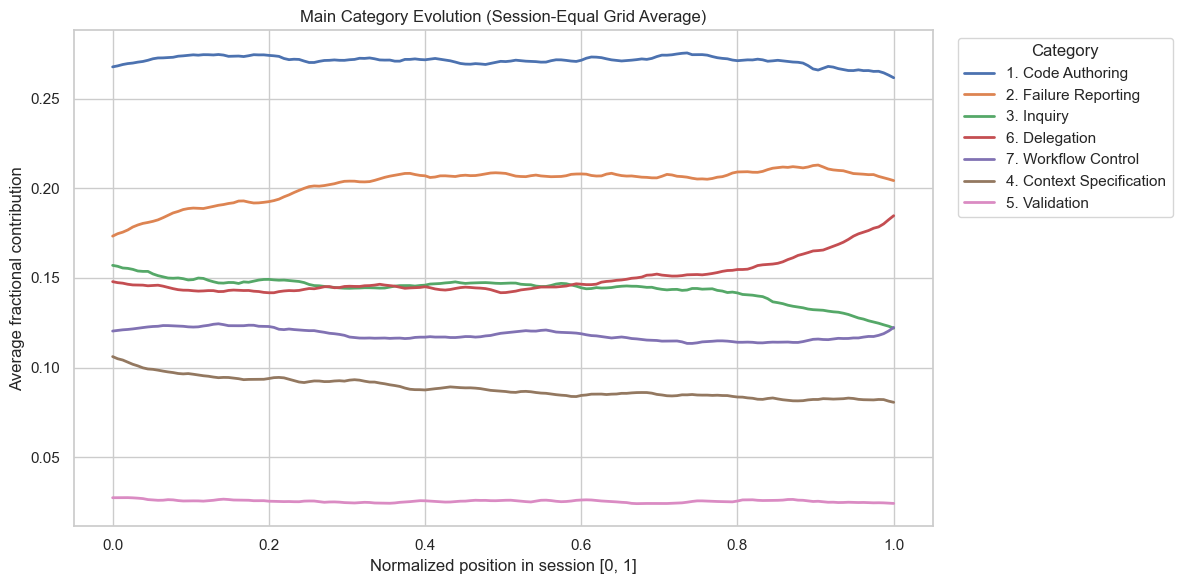

In [14]:
plot_category_curves(main_curve, "Main Category Evolution (Session-Equal Grid Average)")

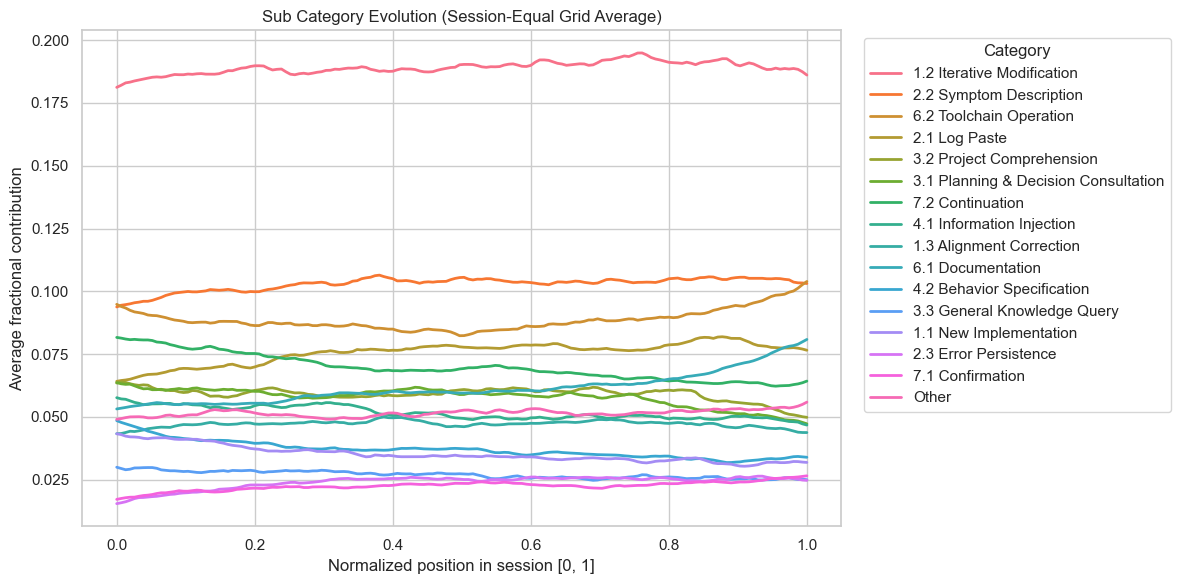

In [15]:
plot_category_curves(sub_curve, "Sub Category Evolution (Session-Equal Grid Average)")

## 5.1) Linear Trend Quantification for Category Curves

For each category curve, run linear regression with:
- `X`: normalized position in `[0, 1]`
- `Y`: average fractional contribution on the curve

The slope is the trend magnitude.

In [16]:
def regression_report_from_category_curve(curve: pd.DataFrame) -> pd.DataFrame:
    categories = curve["category"].drop_duplicates().tolist()
    results = []
    for category in categories:
        y = curve.loc[curve["category"] == category, "value_interp"].to_numpy(
            dtype=float
        )
        x = np.linspace(0, 1, len(y))
        slope, intercept, r, p, se = stats.linregress(x, y)
        results.append(
            {
                "category": category,
                "slope": slope,
                "r_squared": r**2,
                "p_value": p,
                "intercept": intercept,
                "std_err": se,
            }
        )
    return (
        pd.DataFrame(results)
        .sort_values("slope", ascending=False)
        .reset_index(drop=True)
    )


main_trend_report = regression_report_from_category_curve(main_curve)
sub_trend_report = regression_report_from_category_curve(sub_curve)

print("Main category trend report")
display(main_trend_report)

print("Sub category trend report")
display(sub_trend_report)

Main category trend report


,category,slope,r_squared,p_value,intercept,std_err
0,6. Delegation,0.025825,0.609627,2.864951e-33,0.137121,0.001665
1,2. Failure Reporting,0.025678,0.659353,7.654877e-38,0.189612,0.001487
2,5. Validation,-0.001040,0.172995,6.670787e-08,0.025952,0.000183
3,1. Code Authoring,-0.004038,0.215960,9.880255e-10,0.273343,0.000620
4,7. Workflow Control,-0.008074,0.569627,5.415752e-30,0.122323,0.000566
5,4. Context Specification,-0.018541,0.897732,3.805726e-78,0.097887,0.000504
6,3. Inquiry,-0.019810,0.704657,1.251547e-42,0.153761,0.001033


Sub category trend report


,category,slope,r_squared,p_value,intercept,std_err
0,6.1 Documentation,0.019205,0.822737,9.836188e-60,0.051821,0.000718
1,2.1 Log Paste,0.012206,0.702973,1.941402e-42,0.069464,0.000639
2,2.2 Symptom Description,0.006941,0.566609,9.299205e-30,0.099423,0.000489
3,6.2 Toolchain Operation,0.006620,0.211883,1.486309e-09,0.085299,0.001029
4,2.3 Error Persistence,0.006531,0.570874,4.326892e-30,0.020726,0.000456
5,1.2 Iterative Modification,0.006065,0.514874,5.752449e-26,0.186014,0.000474
6,7.1 Confirmation,0.005134,0.725909,3.925208e-45,0.019907,0.000254
7,Other,0.002948,0.428347,1.936984e-20,0.050046,0.000274
8,1.3 Alignment Correction,0.000062,0.000188,8.650295e-01,0.047078,0.000362
9,3.3 General Knowledge Query,-0.004421,0.852398,7.274679e-66,0.029171,0.000148


## 6) Message-Level Metrics Evolution

Analyze two message-level metrics over normalized position:
- Message length (`# chars`)
- Number of labels (`# labels`)

In [17]:
def compute_message_metric_curve(
    msg_df: pd.DataFrame,
    metric_col: str,
    grid_size: int,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    sequences = build_session_metric_sequences(msg_df, metric_col=metric_col)
    curve = session_equal_weight_curve_from_sequences(sequences, grid_size=grid_size)

    exact = curve[["pos_norm", "value_interp", "support_interp"]].copy()
    exact = exact.rename(
        columns={"value_interp": "mean_value", "support_interp": "support"}
    )
    exact["median_value"] = np.nan
    return exact, curve


chars_exact, chars_curve = compute_message_metric_curve(
    msg_df=msg_f,
    metric_col="msg_chars",
    grid_size=SMOOTH_GRID_SIZE,
)

labels_exact, labels_curve = compute_message_metric_curve(
    msg_df=msg_f,
    metric_col="labels_in_message",
    grid_size=SMOOTH_GRID_SIZE,
)

In [18]:
def plot_metric_curve(curve_df: pd.DataFrame, title: str, y_label: str):
    plt.figure(figsize=(10, 5))
    sns.lineplot(data=curve_df, x="pos_norm", y="value_interp", linewidth=2)
    plt.title(title)
    plt.xlabel("Normalized position in session [0, 1]")
    plt.ylabel(y_label)
    plt.tight_layout()
    plt.show()

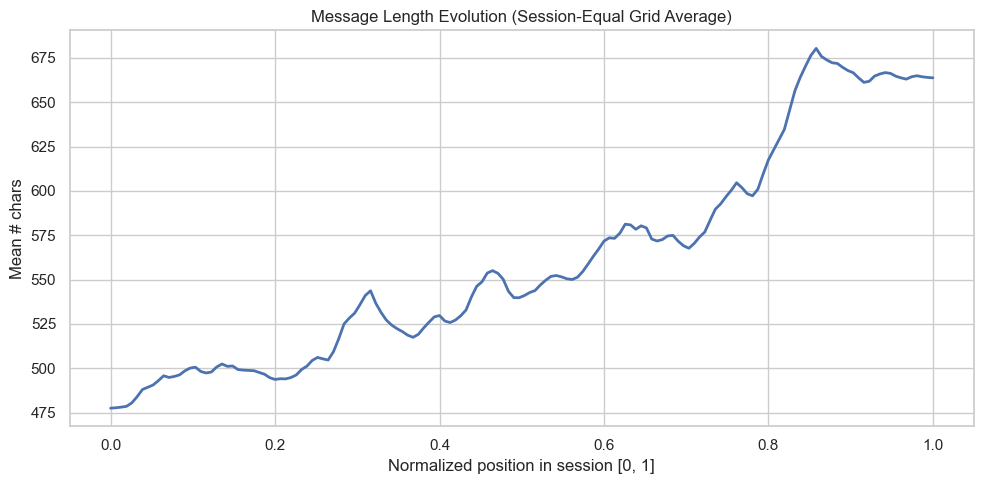

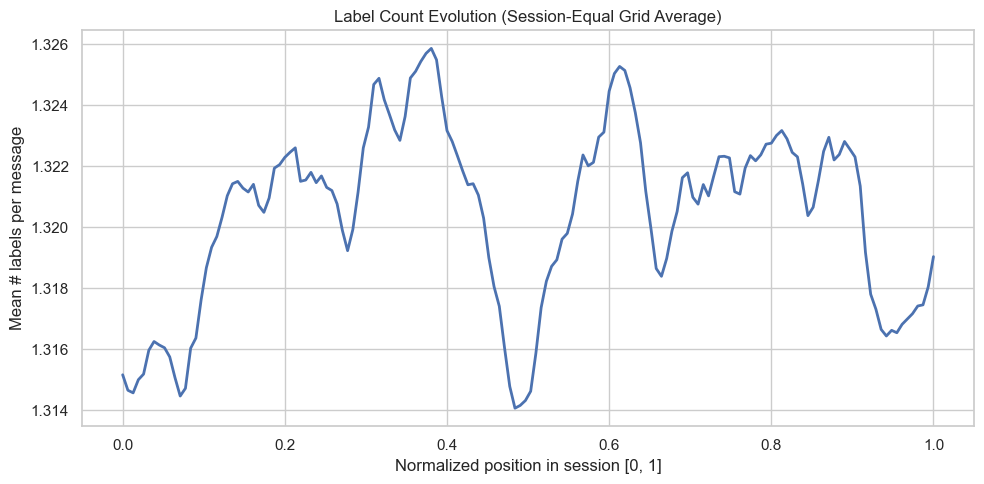

In [19]:
plot_metric_curve(
    chars_curve,
    "Message Length Evolution (Session-Equal Grid Average)",
    "Mean # chars",
)
plot_metric_curve(
    labels_curve,
    "Label Count Evolution (Session-Equal Grid Average)",
    "Mean # labels per message",
)

## 6.1) Linear Trend Quantification for Message-Level Curves

Run linear regression on each message-level trend curve using normalized position as `X` and curve value as `Y`.

In [20]:
def regression_report_single_curve(
    curve: pd.DataFrame, category_name: str
) -> pd.DataFrame:
    y = curve["value_interp"].to_numpy(dtype=float)
    x = np.linspace(0, 1, len(y))
    slope, intercept, r, p, se = stats.linregress(x, y)
    return pd.DataFrame(
        [
            {
                "category": category_name,
                "slope": slope,
                "r_squared": r**2,
                "p_value": p,
                "intercept": intercept,
                "std_err": se,
            }
        ]
    )


chars_trend_report = regression_report_single_curve(chars_curve, "message_length_chars")
labels_trend_report = regression_report_single_curve(labels_curve, "labels_per_message")

metric_trend_report = pd.concat(
    [chars_trend_report, labels_trend_report], ignore_index=True
)
print("Message-level trend report")
display(metric_trend_report)

Message-level trend report


,category,slope,r_squared,p_value,intercept,std_err
0,message_length_chars,198.386604,0.912768,1.815668e-83,461.481532,4.942077
1,labels_per_message,0.001594,0.024465,5.118845e-02,1.319661,0.000811


## 7) Quality Checks

In [21]:
checks = {
    "pos_norm_in_[0,1]": bool(
        ((msg_f["pos_norm"] >= 0.0) & (msg_f["pos_norm"] <= 1.0)).all()
    ),
    "all_kept_sessions_meet_threshold": (
        bool((msg_f.groupby("sha")["index_in_chat"].nunique() >= MIN_MESSAGES).all())
        if len(msg_f)
        else True
    ),
    "fractional_weights_sum_to_1": bool(
        np.allclose(weight_check["weight_sum"].to_numpy(), 1.0, atol=1e-9)
    ),
}

pd.DataFrame(list(checks.items()), columns=["check", "passed"])

,check,passed
0,"pos_norm_in_[0,1]",True
1,all_kept_sessions_meet_threshold,True
2,fractional_weights_sum_to_1,True


## 8) Optional Export

Exports are disabled by default. Set `SAVE_RESULTS = True` in the config cell to write outputs under `RESULTS_DIR` (default: `results`).

In [22]:
if SAVE_RESULTS:
    main_exact.to_csv(RESULTS_DIR / "main_category_exact.csv", index=False)
    main_curve.to_csv(RESULTS_DIR / "main_category_curve.csv", index=False)
    sub_exact.to_csv(RESULTS_DIR / "sub_category_exact.csv", index=False)
    sub_curve.to_csv(RESULTS_DIR / "sub_category_curve.csv", index=False)
    chars_exact.to_csv(RESULTS_DIR / "message_chars_exact.csv", index=False)
    chars_curve.to_csv(RESULTS_DIR / "message_chars_curve.csv", index=False)
    labels_exact.to_csv(RESULTS_DIR / "labels_per_message_exact.csv", index=False)
    labels_curve.to_csv(RESULTS_DIR / "labels_per_message_curve.csv", index=False)
    diagnostics.to_csv(RESULTS_DIR / "session_filter_diagnostics.csv", index=False)
    print(f"Saved outputs to: {RESULTS_DIR.resolve()}")
else:
    print("SAVE_RESULTS is False. No files were written.")

SAVE_RESULTS is False. No files were written.


## 9) Brief Interpretation Template

Use this section after running all cells:
- Which main categories rise or fall from early to late session?
- Which sub categories dominate the middle vs ending phase?
- Does message length increase, decrease, or stay stable over normalized progress?
- Does label count per message become simpler or more complex later in sessions?